In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("whldataset.csv")

In [3]:
df.isna().sum()

game_id                     0
record_id                   0
home_team                   0
away_team                   0
went_ot                     0
home_off_line               0
home_def_pairing            0
away_off_line               0
away_def_pairing            0
home_goalie                 0
away_goalie                 0
toi                         0
home_assists                0
home_shots                  0
home_xg                     0
home_max_xg                 0
home_goals                  0
away_assists                0
away_shots                  0
away_xg                     0
away_max_xg                 0
away_goals                  0
home_penalties_committed    0
home_penalty_minutes        0
away_penalties_committed    0
away_penalty_minutes        0
dtype: int64

In [4]:
df.head()

,game_id,record_id,home_team,away_team,went_ot,home_off_line,home_def_pairing,away_off_line,away_def_pairing,home_goalie,...,home_goals,away_assists,away_shots,away_xg,away_max_xg,away_goals,home_penalties_committed,home_penalty_minutes,away_penalties_committed,away_penalty_minutes
0,game_1,record_1,thailand,pakistan,0,PP_kill_dwn,PP_kill_dwn,PP_up,PP_up,player_id_142,...,0,2,9,1.4645,0.2166,1,7,14,1,2
1,game_1,record_2,thailand,pakistan,0,second_off,second_def,second_off,second_def,player_id_142,...,0,2,1,0.0928,0.0928,1,0,0,0,0
2,game_1,record_3,thailand,pakistan,0,first_off,second_def,second_off,second_def,player_id_142,...,0,0,2,0.1880,0.0940,0,0,0,0,0
3,game_1,record_4,thailand,pakistan,0,second_off,first_def,second_off,first_def,player_id_142,...,0,0,1,0.0727,0.0727,0,0,0,0,0
4,game_1,record_5,thailand,pakistan,0,second_off,second_def,first_off,second_def,player_id_142,...,0,2,1,0.0769,0.0769,1,0,0,0,0


In [5]:
cols_needed = [
    'game_id',
    'home_team', 'away_team',
    'went_ot',
    'home_goals', 'away_goals'
]

cleaned = df[cols_needed].copy()

In [6]:
cleaned.head()

,game_id,home_team,away_team,went_ot,home_goals,away_goals
0,game_1,thailand,pakistan,0,0,1
1,game_1,thailand,pakistan,0,0,1
2,game_1,thailand,pakistan,0,0,0
3,game_1,thailand,pakistan,0,0,0
4,game_1,thailand,pakistan,0,0,1


In [7]:
game_summary = (
    cleaned
    .groupby(['game_id', 'home_team', 'away_team', 'went_ot'], as_index=False)
    .agg(
        home_goals=('home_goals', 'sum'),
        away_goals=('away_goals', 'sum')
    )
)

game_summary.head()

,game_id,home_team,away_team,went_ot,home_goals,away_goals
0,game_1,thailand,pakistan,0,1,3
1,game_10,switzerland,kazakhstan,0,4,3
2,game_100,serbia,rwanda,0,4,5
3,game_1000,brazil,netherlands,0,5,0
4,game_1001,india,morocco,0,2,3


In [8]:
home_games = pd.DataFrame({
    "game_id" : game_summary["game_id"],
    "team" : game_summary["home_team"],
    "opponent" : game_summary["away_team"],
    "went_ot" : game_summary["went_ot"],
    "goals_for" : game_summary["home_goals"],
    "goals_against" : game_summary["away_goals"],
})

away_games = pd.DataFrame({
    "game_id" : game_summary["game_id"],
    "team" : game_summary["away_team"],
    "opponent" : game_summary["home_team"],
    "went_ot" : game_summary["went_ot"],
    "goals_for" : game_summary["away_goals"],
    "goals_against" : game_summary["home_goals"],
})

conditions_home = [
    (game_summary["home_goals"] > game_summary["away_goals"]) & (game_summary["went_ot"] == 0),
    (game_summary["home_goals"] > game_summary["away_goals"]) & (game_summary["went_ot"] == 1),
    (game_summary["home_goals"] < game_summary["away_goals"]) & (game_summary["went_ot"] == 1),
    (game_summary["home_goals"] < game_summary["away_goals"]) & (game_summary["went_ot"] == 0),
]
choices = ["win", "ot_win", "ot_loss", "loss"]
home_games["result"] = np.select(conditions_home, choices, default=None)

conditions_away = [
    (game_summary["away_goals"] > game_summary["home_goals"]) & (game_summary["went_ot"] == 0),
    (game_summary["away_goals"] > game_summary["home_goals"]) & (game_summary["went_ot"] == 1),
    (game_summary["away_goals"] < game_summary["home_goals"]) & (game_summary["went_ot"] == 1),
    (game_summary["away_goals"] < game_summary["home_goals"]) & (game_summary["went_ot"] == 0),
]
away_games["result"] = np.select(conditions_away, choices, default=None)

all_games = pd.concat([home_games, away_games], ignore_index=True)
all_games

,game_id,team,opponent,went_ot,goals_for,goals_against,result
0,game_1,thailand,pakistan,0,1,3,loss
1,game_10,switzerland,kazakhstan,0,4,3,win
2,game_100,serbia,rwanda,0,4,5,loss
3,game_1000,brazil,netherlands,0,5,0,win
4,game_1001,india,morocco,0,2,3,loss
...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,1,3,4,ot_loss
2620,game_996,indonesia,kazakhstan,0,5,0,win
2621,game_997,south_korea,canada,0,5,3,win
2622,game_998,uae,switzerland,0,2,4,loss


In [9]:
league_table = (
    all_games
    .groupby("team", as_index=False)
    .agg(
        games_played=("game_id", "count"),
        wins=("result", lambda s: (s=="win").sum()),
        losses=("result", lambda s: (s=="loss").sum()),
        OT_wins=("result", lambda s: (s=="ot_win").sum()),
        OT_losses=("result", lambda s: (s=="ot_loss").sum()),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum")
    )
)

league_table["goal_diff"] = league_table["goals_for"] - league_table["goals_against"]
league_table["points"] = (
    2 * league_table["wins"]
    + 2 * league_table["OT_wins"]
    + 1 * league_table["OT_losses"]       
)

# sort for rankings
league_table = league_table.sort_values(
    by=["points", "goal_diff", "goals_for"],
    ascending=[False, False, False]
).reset_index(drop=True)

league_table.insert(0, "rank", league_table.index + 1)
league_table

,rank,team,games_played,wins,losses,OT_wins,OT_losses,goals_for,goals_against,goal_diff,points
0,1,brazil,82,51,18,7,6,276,189,87,122
1,2,netherlands,82,42,22,12,6,243,174,69,114
2,3,peru,82,38,22,14,8,256,178,78,112
3,4,thailand,82,44,25,6,7,294,248,46,107
4,5,pakistan,82,41,25,8,8,263,212,51,106
5,6,india,82,42,27,7,6,221,193,28,104
6,7,china,82,36,28,11,7,239,193,46,101
7,8,panama,82,36,27,10,9,255,213,42,101
8,9,iceland,82,38,27,8,9,238,209,29,101
9,10,philippines,82,30,26,13,13,198,186,12,99


In [10]:
league_table.to_csv('league_table.csv')

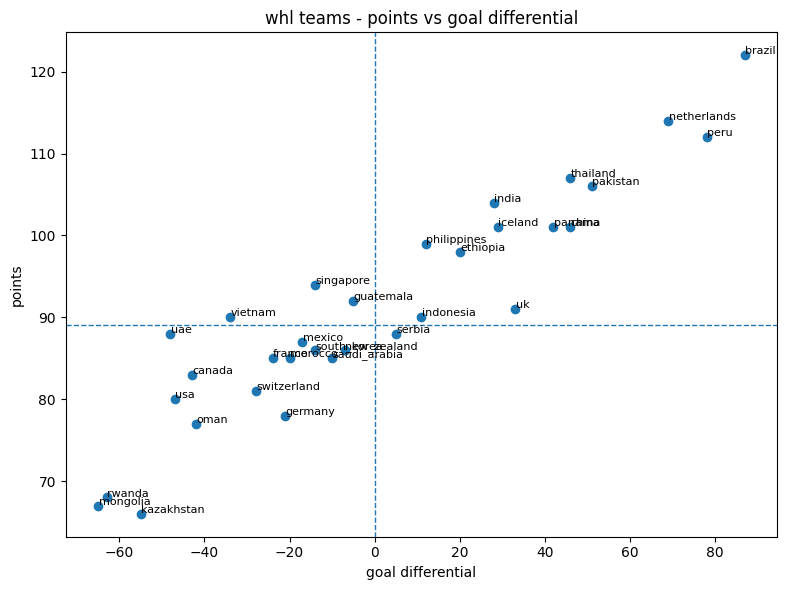

In [11]:
fig, ax = plt.subplots(figsize=(8,6))

x = league_table["goal_diff"]
y = league_table["points"]

ax.scatter(x, y)

for _, row in league_table.iterrows():
    ax.text(row["goal_diff"] + 0.1, row["points"] + 0.1, row["team"], fontsize=8)

ax.axvline(0, linestyle="--", linewidth=1)
median_points = league_table["points"].median()
ax.axhline(median_points, linestyle="--", linewidth=1)

ax.set_title("whl teams - points vs goal differential")
ax.set_xlabel("goal differential")
ax.set_ylabel("points")

plt.tight_layout()
plt.show()